In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from pysr import PySRRegressor
import matplotlib.pyplot as plt

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [6]:
np.random.seed(42)
n_train = 100
mass = np.random.uniform(1, 10, n_train)
velocity = np.random.uniform(0, 20, n_train) 

In [7]:
kinetic_energy_train = 0.5 * mass * velocity**2
noise = np.random.normal(0, 5, n_train)
kinetic_energy_train_noisy = kinetic_energy_train + noise

X = np.column_stack([mass, velocity])
y = kinetic_energy_train_noisy

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=33)

In [8]:
model = PySRRegressor(
    niterations=40,
    binary_operators=["+", "*", "/", "-"],
    unary_operators=["square", "cube", "sqrt"],
    populations=20,
    population_size=50,
    ncycles_per_iteration=550,
    maxsize=20, 
    batching=True,
    batch_size=50,
    verbosity=1,
    random_state=42,
    model_selection="best",  
)
model.fit(X_train, y_train, variable_names=["m", "v"])

/home/andre/programing/lamfo/ic_andre_rimes/env/lib/python3.10/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/andre/programing/lamfo/ic_andre_rimes/env/lib/python3.10/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.370e+05  0.000e+00  y = 324.39
2           1.198e+05  1.254e-01  y = square(v)
3           6.022e+04  6.803e-01  y = v * 37.839
4           4.088e+04  3.817e-01  y = square(m) * v
5           1.851e+04  7.880e-01  y = square(v) * sqrt(m)
6           2.401e+01  6.646e+00  y = (m * square(v)) * 0.50055
7           2.401e+01  2.950e-05  y = square(v * sqrt(m * 0.50058))
8           2.350e+01  2.108e-02  y = m * square((v + -0.049391) / 1.4093)
9           2.344e+01  2.657e-03  y = square(sqrt(m) * ((v * 0.70925) + -0.028202))
10          2.301e+01  1.872e-02  y = (m * square((v / 1.4082) + -0.054011)) + 1.4082
11          2.298e+01  1.267e-03  y = square(((v + -0.069573) * sqrt(m)) * 0.71014) + 1.0844
14          2.297e+01  1.472e-04  y = square(((v + -0.069573) * sqrt(m)) * 0.71014) + (2.125...
                                      2

[ Info: Final population:
[ Info: Results saved to:


,model_selection,'best'
,binary_operators,"['+', '*', ...]"
,unary_operators,"['square', 'cube', ...]"
,expression_spec,None
,niterations,40
,populations,20
,population_size,50
,max_evals,None
,maxsize,20
,maxdepth,None
,warmup_maxsize_by,None


  - outputs/20251005_175027_C3XYD1/hall_of_fame.csv


In [9]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

best_eq = model.get_best()
best_equation = best_eq['equation']

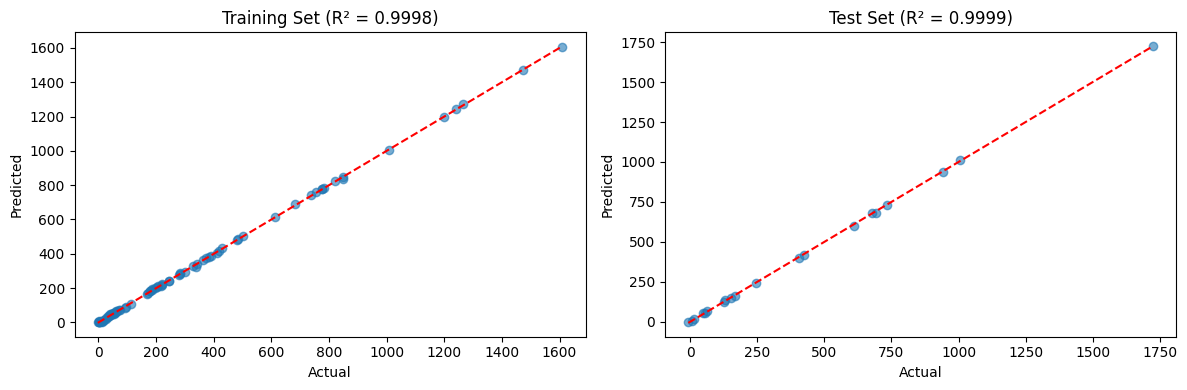

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(y_train, y_pred_train, alpha=0.6)
ax1.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
ax1.set_xlabel('Actual')
ax1.set_ylabel('Predicted')
ax1.set_title(f'Training Set (R² = {r2_train:.4f})')

ax2.scatter(y_test, y_pred_test, alpha=0.6)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax2.set_xlabel('Actual')
ax2.set_ylabel('Predicted')
ax2.set_title(f'Test Set (R² = {r2_test:.4f})')

plt.tight_layout()
plt.show()

In [11]:
best_eq = model.get_best()
print(f"Best equation: {best_eq['equation']}")
print(f"Complexity: {best_eq['complexity']} nodes")

print("\nFull equations found:")
print(model.equations_[['complexity', 'loss', 'score', 'equation']])

Best equation: (m * square(v)) * 0.5005496
Complexity: 6 nodes

Full equations found:
    complexity           loss     score  \
0            1  137049.730000  0.000000   
1            2  119830.000000  0.134270   
2            3   60223.820000  0.688006   
3            4   40881.168000  0.387398   
4            5   18510.438000  0.792335   
5            6      24.006313  6.647773   
6            7      24.005560  0.000031   
7            8      23.504784  0.021081   
8            9      23.442370  0.002659   
9           10      23.007542  0.018723   
10          11      22.978373  0.001269   
11          14      22.968182  0.000148   
12          15      22.329441  0.028204   
13          16      22.113360  0.009724   
14          17      22.070160  0.001955   
15          18      21.718548  0.016060   
16          20      21.326546  0.009107   

                                             equation  
0                                           324.38623  
1                          

In [12]:
import sympy as sp
from IPython.display import display, Latex

equation_sympy = model.sympy()
equation_latex = sp.latex(equation_sympy)

table_latex = f"""
\\begin{{array}}{{|l|c|}}
\\hline
\\textbf{{Metric}} & \\textbf{{Value}} \\\\
\\hline
\\text{{Equation}} & {equation_latex} \\\\
\\hline
R^2 \\text{{ (Train)}} & {r2_train:.4f} \\\\
\\hline
R^2 \\text{{ (Test)}} & {r2_test:.4f} \\\\
\\hline
\\text{{RMSE (Train)}} & {rmse_train:.4f} \\\\
\\hline
\\text{{RMSE (Test)}} & {rmse_test:.4f} \\\\
\\hline
\\end{{array}}
"""

display(Latex(table_latex))

<IPython.core.display.Latex object>